# Data Preprocessing 
Load raw data, visualize, map labels, chunk windows, and normalize.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('d:/Swin documents/COS40007-Project/backend')

# Importing libraries

In [2]:
from types import SimpleNamespace
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from utils.seed import set_seed
from utils.device import get_device
from data.preprocessing import (
    create_windows,
    clean_features,
    normalize_features,
    get_feature_columns,
 )
from data.motion_dataset import MotionDataset

# Config (no Hydra)
seed = 42
device = get_device("auto")
set_seed(seed)

sensor_types = ["Segment Velocity", "Segment Acceleration"]
video_suffix = None
window_size = 60
stride = 30
batch_size = 32
num_workers = 0
val_split = 0.2


# Read data 

In [3]:
print("[phase=data] loading P1 + P2 datasets")
DATA_DIR = PROJECT_ROOT / "output_data"

# P1 source
p1_dfs = [
    pd.read_csv(DATA_DIR / "P1_boning.csv"),
    pd.read_csv(DATA_DIR / "P1_slicing.csv"),
]
p1_raw_df = pd.concat(p1_dfs, ignore_index=True)

# P2 source
p2_dfs = [
    pd.read_csv(DATA_DIR / "P2_boning.csv"),
    pd.read_csv(DATA_DIR / "P2_slicing.csv"),
]
p2_raw_df = pd.concat(p2_dfs, ignore_index=True)

# Keep velocity + acceleration only
p1_raw_df = p1_raw_df[p1_raw_df["sensor_type"].isin(sensor_types)]
p2_raw_df = p2_raw_df[p2_raw_df["sensor_type"].isin(sensor_types)]

# Optional video suffix filter
if video_suffix is not None:
    p1_raw_df = p1_raw_df[p1_raw_df["video_id"].str.endswith(video_suffix)]
    p2_raw_df = p2_raw_df[p2_raw_df["video_id"].str.endswith(video_suffix)]

def merge_velocity_and_acceleration(df):
    vel_df = df[df["sensor_type"] == "Segment Velocity"].copy()
    acc_df = df[df["sensor_type"] == "Segment Acceleration"].copy()

    if vel_df.empty or acc_df.empty:
        raise ValueError("Both Segment Velocity and Segment Acceleration rows are required.")

    base_feature_cols = get_feature_columns(vel_df)

    id_cols = [
        c for c in ["video_id", "Frame", "Label", "person_id", "activity_type", "knife_sharpness_score"]
        if c in vel_df.columns
    ]

    vel_df = vel_df[id_cols + base_feature_cols].rename(
        columns={c: f"{c}_vel" for c in base_feature_cols}
    )
    acc_df = acc_df[["video_id", "Frame"] + base_feature_cols].rename(
        columns={c: f"{c}_acc" for c in base_feature_cols}
    )

    merged_df = vel_df.merge(
        acc_df,
        on=["video_id", "Frame"],
        how="inner",
        validate="one_to_one",
    )
    return merged_df, base_feature_cols

p1_df, base_feature_cols = merge_velocity_and_acceleration(p1_raw_df)
p2_df, _ = merge_velocity_and_acceleration(p2_raw_df)

velocity_feature_cols = [f"{c}_vel" for c in base_feature_cols]
acceleration_feature_cols = [f"{c}_acc" for c in base_feature_cols]
feature_cols = velocity_feature_cols + acceleration_feature_cols

assert p1_df["Label"].nunique() > 1, "Only one class left after filtering - train/val invalid"
assert p2_df["Label"].nunique() > 1, "Only one class left after filtering - test invalid"

print(f"[phase=data] p1_rows={len(p1_df)} p2_rows={len(p2_df)}")
print(f"[phase=data] velocity_features={len(velocity_feature_cols)} acceleration_features={len(acceleration_feature_cols)} total_features={len(feature_cols)}")
p1_df.head()


[phase=data] loading P1 + P2 datasets


C:\Users\PCPV\AppData\Local\Temp\ipykernel_18900\3268270065.py:6: DtypeWarning: Columns (0: Label) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv(DATA_DIR / "P1_boning.csv"),
C:\Users\PCPV\AppData\Local\Temp\ipykernel_18900\3268270065.py:7: DtypeWarning: Columns (0: Label) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv(DATA_DIR / "P1_slicing.csv"),


[phase=data] p1_rows=266924 p2_rows=208908
[phase=data] velocity_features=66 acceleration_features=66 total_features=132


,video_id,Frame,Label,person_id,activity_type,knife_sharpness_score,L5 x_vel,L5 y_vel,L5 z_vel,L3 x_vel,...,Left Upper Leg z_acc,Left Lower Leg x_acc,Left Lower Leg y_acc,Left Lower Leg z_acc,Left Foot x_acc,Left Foot y_acc,Left Foot z_acc,Left Toe x_acc,Left Toe y_acc,Left Toe z_acc
0,MVN-J-Boning-64-001,0,4,P1,boning,64,0.016263,-0.095142,0.221275,0.016263,...,-1.463229,-1.665037,-2.060481,-1.485525,-2.185359,-1.194785,-1.663235,-2.185359,-1.194785,-1.663235
1,MVN-J-Boning-64-001,1,4,P1,boning,64,0.001253,-0.126477,0.188341,-0.007620,...,-1.230812,-0.752149,-2.689504,-1.314239,-1.060466,-1.162565,-1.845591,-1.064713,-1.147108,-1.845636
2,MVN-J-Boning-64-001,2,4,P1,boning,64,-0.013758,-0.157811,0.155406,-0.031503,...,-1.454299,0.183840,-2.178955,-1.321744,-0.220440,-1.530509,-1.658241,-0.227187,-1.514522,-1.657987
3,MVN-J-Boning-64-001,3,4,P1,boning,64,-0.022041,-0.178102,0.134543,-0.045098,...,-1.521032,0.540981,-0.951495,-1.324380,-0.175790,-1.007643,-1.326566,-0.091278,-0.986575,-1.316862
4,MVN-J-Boning-64-001,4,4,P1,boning,64,-0.020406,-0.179536,0.134429,-0.042620,...,-0.523328,0.754778,-0.402592,-0.509365,0.347853,-0.509991,-0.538392,0.335083,-0.493518,-0.537629


# Visualize Data (Optional)

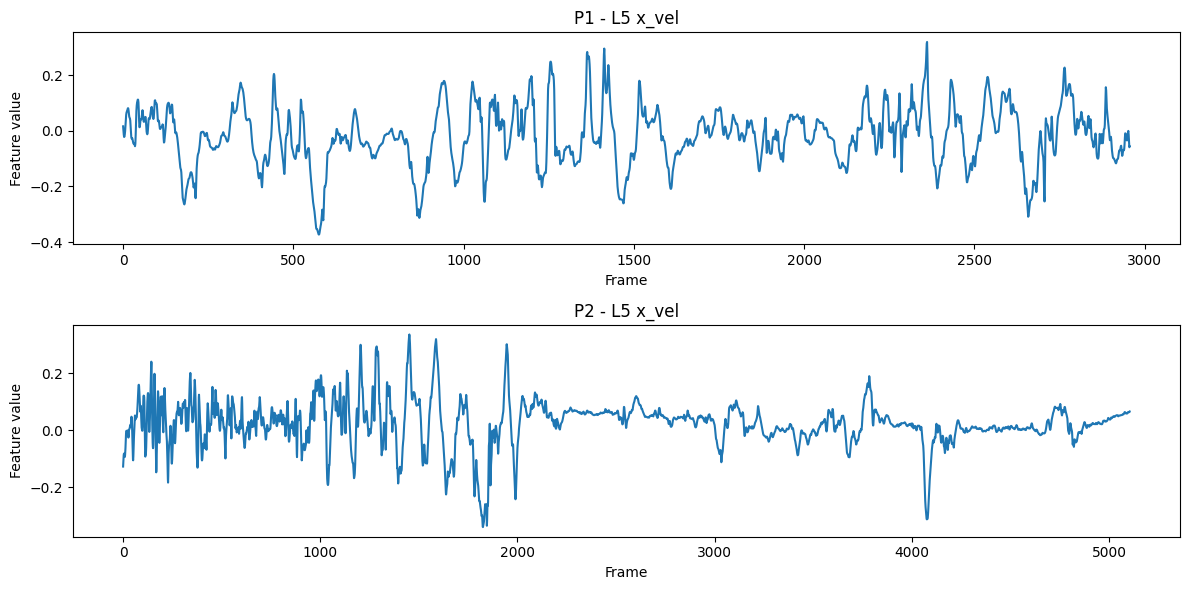

In [4]:
import matplotlib.pyplot as plt

# choose feature to visualize
feature_name = "L5 x_vel"   # change to any feature column

# optionally select one video from each dataset
p1_sample = p1_df[p1_df["video_id"] == p1_df["video_id"].iloc[0]]
p2_sample = p2_df[p2_df["video_id"] == p2_df["video_id"].iloc[0]]

# frame index
x1 = range(len(p1_sample))
x2 = range(len(p2_sample))

# create horizontal stacked plots
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=False)

# P1 plot
axes[0].plot(x1, p1_sample[feature_name])
axes[0].set_title(f"P1 - {feature_name}")
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("Feature value")

# P2 plot
axes[1].plot(x2, p2_sample[feature_name])
axes[1].set_title(f"P2 - {feature_name}")
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("Feature value")

plt.tight_layout()
plt.show()

# Process Data: Split Train/Test/Val

In [5]:
import pandas as pd

print("[phase=data] Unique labels and their counts per activity:")

# 1. Combine both datasets to get the overall count
combined_df = pd.concat([p1_df, p2_df], ignore_index=True)

# 2. Group by activity_type and Label to calculate counts
overall_label_counts = combined_df.groupby(
    ['Label']
).size().reset_index(name='Count')

# 3. Print the detailed breakdown
print(overall_label_counts.to_string(index=False))


[phase=data] Unique labels and their counts per activity:
                    Label  Count
                        0  62948
                        1  13102
                        2  43149
                        3  16984
                        4 213592
                        5  34193
                        6   7162
                        7   4838
                        8  16325
                        0    529
                        1   1566
                        2    587
             2 - Steeling   1469
                        3    479
             3 - Reaching   3282
                        4   5540
              4 - Cutting  24550
                        5    117
              5 - Slicing  18779
7 - Placing/ Manipulating    787
             8 - Dropping   5854


# Relabel

In [6]:
print("[phase=data] Cleaning inconsistent labels")

label_mapping = {
    '0- Idle': 0,
    '0 - Idle': 0,
    '1- Walking': 1,
    '1 - Walking': 1,
    '2- Steeling': 2,
    '2 - Steeling': 2,
    '3- Reaching': 3,
    '3 - Reaching': 3,
    '4- Cutting': 4,
    '4 - Cutting': 4,
    '4 - Cutting (Big Pieces)': 4,
    '4 - Cutting (Big Piece)': 4,
    '4- Cutting (big piece)': 4,
    '4 - Cutting (offloading bone from Carcass)': 4,
    '5- Dropping': 8,
    '5 - Dropping': 8,
    '5 - Slicing': 5,
    '6 - Pulling': 6,
    '7 - Placing/ Manipulating': 7,
    '8 - Dropping': 8,
}

p1_df['Label'] = p1_df['Label'].replace(label_mapping)
p2_df['Label'] = p2_df['Label'].replace(label_mapping)

for df in [p1_df, p2_df]:
    df['Label'] = pd.to_numeric(df['Label'], errors='coerce')

for df in [p1_df, p2_df]:
    boning_mask = df['activity_type'].str.lower().eq('boning')
    df.loc[boning_mask & (df['Label'] == 5), 'Label'] = 8

for df in [p1_df, p2_df]:
    if df['Label'].isna().any():
        print("[warning] Found non-numeric labels after mapping")
    df['Label'] = df['Label'].astype('int64')

# Binary target: label 4 (cutting) -> 1, all remaining labels -> 0
for df in [p1_df, p2_df]:
    df['Label'] = (df['Label'] == 4).astype('int64')

combined_df = pd.concat([p1_df, p2_df], ignore_index=True)

print("[phase=data] Binary label mapping applied: cutting=1, non-cutting=0")
print("[phase=data] Unique video_id values after relabel:")
unique_video_ids = sorted(combined_df['video_id'].dropna().astype(str).unique().tolist())
print(f"total_video_ids={len(unique_video_ids)}")
for video_id in unique_video_ids:
    print(video_id)

overall_label_counts = combined_df.groupby(['activity_type', 'Label']).size().reset_index(name='Count')
print("\n[phase=data] binary label counts by activity:")
print(overall_label_counts.to_string(index=False))

[phase=data] Cleaning inconsistent labels
[phase=data] Binary label mapping applied: cutting=1, non-cutting=0
[phase=data] Unique video_id values after relabel:
total_video_ids=25
MVN-J-Boning-64-001
MVN-J-Boning-64-002
MVN-J-Boning-64-003
MVN-J-Boning-64-004
MVN-J-Boning-64-005
MVN-J-Boning-64-006
MVN-J-Boning-79-001
MVN-J-Boning-90-001
MVN-J-Boning-90-002
MVN-J-Boning-90-003
MVN-J-Boning-90-004
MVN-J-Slicing-64-001
MVN-J-Slicing-73-001
MVN-J-Slicing-87-001
MVN-S-Boning-63-001
MVN-S-Boning-63-002
MVN-S-Boning-63-003
MVN-S-Boning-76-001
MVN-S-Boning-76-002
MVN-S-Boning-89-001
MVN-S-Boning-89-002
MVN-S-Boning-89-003
MVN-S-Boning-89-004
MVN-S-Slicing-63-001
MVN-S-Slicing-73-001

[phase=data] binary label counts by activity:
activity_type  Label  Count
       boning      0 127140
       boning      1 151989
      slicing      0 105010
      slicing      1  91693


# Feature Engineering

In [7]:
import numpy as np
import pandas as pd

combined_df = pd.concat([p1_df, p2_df], ignore_index=True)

# Build segment list from base xyz feature names (e.g., "L5 x")
segment_names = []
for col in base_feature_cols:
    segment_name, axis = col.rsplit(" ", 1)
    if axis == "x":
        segment_names.append(segment_name)

# Keep stable order, unique only
segment_names = list(dict.fromkeys(segment_names))

engineered_cols = {}

# Baseline features: 22 velocity magnitude + 22 acceleration magnitude
for seg in segment_names:
    vx_col, vy_col, vz_col = f"{seg} x_vel", f"{seg} y_vel", f"{seg} z_vel"
    ax_col, ay_col, az_col = f"{seg} x_acc", f"{seg} y_acc", f"{seg} z_acc"

    vel_mag_col = f"{seg}_vel_mag"
    acc_mag_col = f"{seg}_acc_mag"

    engineered_cols[vel_mag_col] = np.sqrt(
        combined_df[vx_col] ** 2 + combined_df[vy_col] ** 2 + combined_df[vz_col] ** 2
    )
    engineered_cols[acc_mag_col] = np.sqrt(
        combined_df[ax_col] ** 2 + combined_df[ay_col] ** 2 + combined_df[az_col] ** 2
    )

velocity_mag_feature_cols = [f"{seg}_vel_mag" for seg in segment_names]
acceleration_mag_feature_cols = [f"{seg}_acc_mag" for seg in segment_names]

# Baseline total body energy
energy_terms = []
for seg in segment_names:
    energy_terms.extend([
        combined_df[f"{seg} x_vel"] ** 2,
        combined_df[f"{seg} y_vel"] ** 2,
        combined_df[f"{seg} z_vel"] ** 2,
        combined_df[f"{seg} x_acc"] ** 2,
        combined_df[f"{seg} y_acc"] ** 2,
        combined_df[f"{seg} z_acc"] ** 2,
    ])
engineered_cols["total_body_energy"] = np.sum(np.column_stack(energy_terms), axis=1)

# New feature engineering --------------------------------------------------
arm_joints = [
    seg for seg in segment_names
    if any(k in seg for k in ["Shoulder", "Upper Arm", "Forearm", "Hand"])
]
leg_joints = [
    seg for seg in segment_names
    if any(k in seg for k in ["Upper Leg", "Lower Leg", "Foot", "Toe"])
]
arm_leg_joints = list(dict.fromkeys(arm_joints + leg_joints))

spine_head_joints = [seg for seg in segment_names if seg in ["L5", "L3", "T12", "T8", "Neck", "Head"]]
upper_body_joints = list(dict.fromkeys(spine_head_joints + arm_joints))
lower_body_joints = leg_joints
left_body_joints = [seg for seg in segment_names if seg.startswith("Left ")]
right_body_joints = [seg for seg in segment_names if seg.startswith("Right ")]

# 1) Axis-pair magnitudes for arm+leg joints only (velocity + acceleration)
pair_suffixes = [("x", "y", "xy"), ("x", "z", "xz"), ("y", "z", "yz")]
pair_feature_cols = []
for seg in arm_leg_joints:
    for a1, a2, pair_name in pair_suffixes:
        vel_pair_col = f"{seg}_vel_{pair_name}"
        acc_pair_col = f"{seg}_acc_{pair_name}"

        engineered_cols[vel_pair_col] = np.sqrt(
            combined_df[f"{seg} {a1}_vel"] ** 2 + combined_df[f"{seg} {a2}_vel"] ** 2
        )
        engineered_cols[acc_pair_col] = np.sqrt(
            combined_df[f"{seg} {a1}_acc"] ** 2 + combined_df[f"{seg} {a2}_acc"] ** 2
        )

        pair_feature_cols.extend([vel_pair_col, acc_pair_col])

# 2) Motion energy distribution (upper/lower and left/right)
def group_energy(df, joints):
    if len(joints) == 0:
        return pd.Series(np.zeros(len(df)), index=df.index)
    terms = []
    for seg in joints:
        terms.extend([
            df[f"{seg} x_vel"] ** 2,
            df[f"{seg} y_vel"] ** 2,
            df[f"{seg} z_vel"] ** 2,
            df[f"{seg} x_acc"] ** 2,
            df[f"{seg} y_acc"] ** 2,
            df[f"{seg} z_acc"] ** 2,
        ])
    return np.sum(np.column_stack(terms), axis=1)

upper_energy = group_energy(combined_df, upper_body_joints)
lower_energy = group_energy(combined_df, lower_body_joints)
left_energy = group_energy(combined_df, left_body_joints)
right_energy = group_energy(combined_df, right_body_joints)

engineered_cols["upper_body_energy"] = upper_energy
engineered_cols["lower_body_energy"] = lower_energy
engineered_cols["left_body_energy"] = left_energy
engineered_cols["right_body_energy"] = right_energy

eps = 1e-8
ul_denom = upper_energy + lower_energy + eps
lr_denom = left_energy + right_energy + eps

engineered_cols["upper_energy_ratio"] = upper_energy / ul_denom
engineered_cols["lower_energy_ratio"] = lower_energy / ul_denom
engineered_cols["left_energy_ratio"] = left_energy / lr_denom
engineered_cols["right_energy_ratio"] = right_energy / lr_denom

energy_distribution_feature_cols = [
    "upper_energy_ratio",
    "lower_energy_ratio",
    "left_energy_ratio",
    "right_energy_ratio",
]

# Attach all engineered columns at once to avoid DataFrame fragmentation
combined_df = pd.concat([combined_df, pd.DataFrame(engineered_cols)], axis=1)

# Final training features
feature_cols = (
    velocity_mag_feature_cols
    + acceleration_mag_feature_cols
    + ["total_body_energy"]
    + pair_feature_cols
    + energy_distribution_feature_cols
)

print("[phase=features] Feature engineering complete")
print(f"Baseline velocity magnitude features: {len(velocity_mag_feature_cols)}")
print(f"Baseline acceleration magnitude features: {len(acceleration_mag_feature_cols)}")
print("Baseline total body energy features: 1")
print(f"Axis-pair features (arms+legs, vel+acc, xy/xz/yz): {len(pair_feature_cols)}")
print(f"Energy distribution ratio features: {len(energy_distribution_feature_cols)}")
print(f"Total training features: {len(feature_cols)}")
print("Sample features:", feature_cols[:6], "...", feature_cols[-6:])

# Sanity checks for new distribution features
ul_sum = (combined_df["upper_energy_ratio"] + combined_df["lower_energy_ratio"]).mean()
lr_sum = (combined_df["left_energy_ratio"] + combined_df["right_energy_ratio"]).mean()
print(f"[phase=features] mean(upper+lower ratio)={ul_sum:.6f}")
print(f"[phase=features] mean(left+right ratio)={lr_sum:.6f}")

[phase=features] Feature engineering complete
Baseline velocity magnitude features: 22
Baseline acceleration magnitude features: 22
Baseline total body energy features: 1
Axis-pair features (arms+legs, vel+acc, xy/xz/yz): 96
Energy distribution ratio features: 4
Total training features: 145
Sample features: ['L5_vel_mag', 'L3_vel_mag', 'T12_vel_mag', 'T8_vel_mag', 'Neck_vel_mag', 'Head_vel_mag'] ... ['Left Toe_vel_yz', 'Left Toe_acc_yz', 'upper_energy_ratio', 'lower_energy_ratio', 'left_energy_ratio', 'right_energy_ratio']
[phase=features] mean(upper+lower ratio)=1.000000
[phase=features] mean(left+right ratio)=1.000000


In [8]:
print(p1_df["Label"].dtype)

int64


# Dynamic Windows by Label Transitions

Detect activity label changes (without groupby), count frames per label, visualize one sample, then build dynamic windows.

In [9]:
import pandas as pd

print("[phase=runs] Building contiguous label runs by video_id + label change (no groupby)")

combined_df = combined_df.sort_values(["video_id", "Frame"]).reset_index(drop=True)

runs = []
frame_counts = {}
run_counts = {}

start_idx = 0
current_video = combined_df.loc[0, "video_id"]
current_label = int(combined_df.loc[0, "Label"])

for i in range(len(combined_df)):
    label_i = int(combined_df.loc[i, "Label"])
    frame_counts[label_i] = frame_counts.get(label_i, 0) + 1

for i in range(1, len(combined_df)):
    video_i = combined_df.loc[i, "video_id"]
    label_i = int(combined_df.loc[i, "Label"])

    is_boundary = (video_i != current_video) or (label_i != current_label)

    if is_boundary:
        end_idx = i - 1
        start_frame = int(combined_df.loc[start_idx, "Frame"])
        end_frame = int(combined_df.loc[end_idx, "Frame"])
        run_length = end_idx - start_idx + 1

        runs.append({
            "video_id": current_video,
            "label": current_label,
            "start_idx": start_idx,
            "end_idx": end_idx,
            "start_frame": start_frame,
            "end_frame": end_frame,
            "run_length": run_length,
        })

        run_counts[current_label] = run_counts.get(current_label, 0) + 1

        start_idx = i
        current_video = video_i
        current_label = label_i

end_idx = len(combined_df) - 1
start_frame = int(combined_df.loc[start_idx, "Frame"])
end_frame = int(combined_df.loc[end_idx, "Frame"])
run_length = end_idx - start_idx + 1
runs.append({
    "video_id": current_video,
    "label": current_label,
    "start_idx": start_idx,
    "end_idx": end_idx,
    "start_frame": start_frame,
    "end_frame": end_frame,
    "run_length": run_length,
})
run_counts[current_label] = run_counts.get(current_label, 0) + 1

print(f"[phase=runs] total_runs={len(runs)}")
print("[phase=runs] frame count per label:")
for label in sorted(frame_counts):
    print(f"  label {label}: {frame_counts[label]}")

print("[phase=runs] run count per label:")
for label in sorted(run_counts):
    print(f"  label {label}: {run_counts[label]}")

runs_df = pd.DataFrame(runs)
print("[phase=runs] run length stats:")
print(runs_df['run_length'].describe(percentiles=[0.5]).to_string())

[phase=runs] Building contiguous label runs by video_id + label change (no groupby)
[phase=runs] total_runs=615
[phase=runs] frame count per label:
  label 0: 232150
  label 1: 243682
[phase=runs] run count per label:
  label 0: 315
  label 1: 300
[phase=runs] run length stats:
count     615.000000
mean      773.710569
std       795.995155
min        18.000000
50%       459.000000
max      5075.000000


[phase=plot] Plotting one sample video with label transitions
[phase=plot] Sample video: MVN-J-Boning-64-001 (2957 frames)


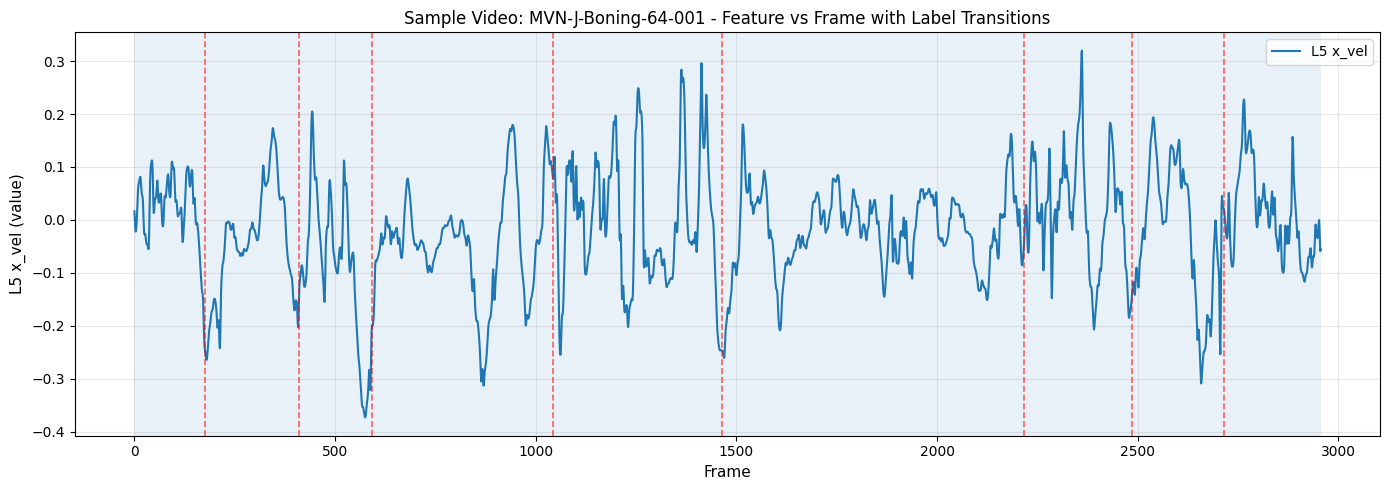

[phase=plot] Red dashed lines indicate label transition points.


In [10]:
import matplotlib.pyplot as plt

print("[phase=plot] Plotting one sample video with label transitions")

# Select first unique video from combined_df
sample_video_id = combined_df["video_id"].unique()[0]
sample_df = combined_df[combined_df["video_id"] == sample_video_id].copy()
sample_df = sample_df.sort_values("Frame").reset_index(drop=True)

print(f"[phase=plot] Sample video: {sample_video_id} ({len(sample_df)} frames)")

# Plot setup
feature_name = "L5 x_vel"  # Choose a sample feature to visualize
fig, ax = plt.subplots(figsize=(14, 5))

# Plot feature value vs Frame
frames = sample_df["Frame"].values
feature_values = sample_df[feature_name].values
ax.plot(frames, feature_values, linewidth=1.5, label=feature_name)

# Mark transition boundaries
transitions = sample_df[sample_df["Label"].diff().fillna(0) != 0]["Frame"].values
for t_frame in transitions:
    ax.axvline(x=t_frame, color='red', linestyle='--', alpha=0.6, linewidth=1.2)

# Shade regions by label
previous_transition = frames[0]
for t_frame in transitions:
    ax.axvspan(previous_transition, t_frame, alpha=0.1)
    previous_transition = t_frame
ax.axvspan(previous_transition, frames[-1], alpha=0.1)

ax.set_xlabel("Frame", fontsize=11)
ax.set_ylabel(f"{feature_name} (value)", fontsize=11)
ax.set_title(f"Sample Video: {sample_video_id} - Feature vs Frame with Label Transitions", fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f"[phase=plot] Red dashed lines indicate label transition points.")


# Normalize Data


In [11]:
# Normalize data (frame-level) using train frames only
from sklearn.preprocessing import StandardScaler

# Hold-out specific videos for validation (to avoid leakage)
TEST_VIDEO_IDS = ["MVN-J-Boning-90-004", "MVN-S-Slicing-63-001", "MVN-S-Boning-89-004"]

# Split by video_id
train_df = combined_df[~combined_df["video_id"].isin(TEST_VIDEO_IDS)].copy()
val_df = combined_df[combined_df["video_id"].isin(TEST_VIDEO_IDS)].copy()

def summarize_stats(df, cols, prefix):
    stats = {
        "min": df[cols].min().min(),
        "max": df[cols].max().max(),
        "mean": df[cols].mean().mean(),
        "std": df[cols].std().mean(),
    }
    print(
        f"{prefix} -> min: {stats['min']:.6f} | max: {stats['max']:.6f} | "
        f"mean: {stats['mean']:.6f} | std: {stats['std']:.6f}"
    )
    return stats

print("[phase=norm] ===== BEFORE normalization =====")
train_before = summarize_stats(train_df, feature_cols, "Train")
val_before = summarize_stats(val_df, feature_cols, "Val")

# Keep copy for pre->post comparison table
train_before_sample = train_df[feature_cols].copy()
val_before_sample = val_df[feature_cols].copy()

# Fit scaler on train frames only
scaler = StandardScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
val_df[feature_cols] = scaler.transform(val_df[feature_cols])

print("[phase=norm] ===== AFTER normalization =====")
train_after = summarize_stats(train_df, feature_cols, "Train")
val_after = summarize_stats(val_df, feature_cols, "Val")

# Representative columns for direct pre->post audit
sample_cols = [
    feature_cols[0],
    feature_cols[len(feature_cols) // 2],
    feature_cols[-1],
]

audit_rows = []
for col in sample_cols:
    audit_rows.append({
        "feature": col,
        "train_mean_before": train_before_sample[col].mean(),
        "train_mean_after": train_df[col].mean(),
        "train_std_before": train_before_sample[col].std(),
        "train_std_after": train_df[col].std(),
        "val_mean_before": val_before_sample[col].mean(),
        "val_mean_after": val_df[col].mean(),
        "val_std_before": val_before_sample[col].std(),
        "val_std_after": val_df[col].std(),
    })

print("[phase=norm] Representative feature pre->post stats:")
print(pd.DataFrame(audit_rows).to_string(index=False))

# Optional full per-column ranges (can be long)
print("[phase=norm] Train per-column min/max after normalization:")
train_min = train_df[feature_cols].min()
train_max = train_df[feature_cols].max()
print(pd.DataFrame({"min": train_min, "max": train_max}).to_string())

print("[phase=norm] Val per-column min/max after normalization:")
val_min = val_df[feature_cols].min()
val_max = val_df[feature_cols].max()
print(pd.DataFrame({"min": val_min, "max": val_max}).to_string())

[phase=norm] ===== BEFORE normalization =====
Train -> min: 0.000009 | max: 78372.567467 | mean: 3.011910 | std: 6.048193
Val -> min: 0.000036 | max: 36628.079326 | mean: 3.637774 | std: 6.889834
[phase=norm] ===== AFTER normalization =====
Train -> min: -4.076351 | max: 109.799146 | mean: 0.000000 | std: 1.000001
Val -> min: -4.055378 | max: 59.770542 | mean: 0.173708 | std: 1.113176
[phase=norm] Representative feature pre->post stats:
             feature  train_mean_before  train_mean_after  train_std_before  train_std_after  val_mean_before  val_mean_after  val_std_before  val_std_after
          L5_vel_mag           1.675507     -1.216081e-16          1.079734         1.000001         1.718629        0.039938        0.999223       0.925436
Left Shoulder_acc_xz           1.003895     -1.761221e-16          1.025116         1.000001         1.203288        0.194509        1.135121       1.107311
  right_energy_ratio           0.586229     -9.854453e-17          0.290372         1.00

## Build Dynamic Windows from Label Transitions


In [12]:
import numpy as np

print("[phase=windows] Building windows from contiguous runs with frame skipping")

WINDOW_SIZE = 60
WINDOW_STRIDE = 30
FRAME_SKIP_STEP = 2

combined_df_norm = combined_df.copy()
combined_df_norm[feature_cols] = scaler.transform(combined_df[feature_cols])

X_windows = []
y_windows = []
window_meta = []
window_lengths = []

for run_idx, run in enumerate(runs):
    run_indices = np.arange(run["start_idx"], run["end_idx"] + 1)
    sampled_indices = run_indices[::FRAME_SKIP_STEP]

    if len(sampled_indices) == 0:
        continue

    if len(sampled_indices) <= WINDOW_SIZE:
        idx_chunk = sampled_indices
        X_windows.append(combined_df_norm.iloc[idx_chunk][feature_cols].to_numpy())
        y_windows.append(run["label"])
        window_lengths.append(len(idx_chunk))
        window_meta.append({
            "run_idx": run_idx,
            "video_id": run["video_id"],
            "label": run["label"],
            "start_frame": int(combined_df.iloc[idx_chunk[0]]["Frame"]),
            "end_frame": int(combined_df.iloc[idx_chunk[-1]]["Frame"]),
            "window_len": len(idx_chunk),
        })
        continue

    starts = list(range(0, len(sampled_indices) - WINDOW_SIZE + 1, WINDOW_STRIDE))

    for start in starts:
        idx_chunk = sampled_indices[start:start + WINDOW_SIZE]
        X_windows.append(combined_df_norm.iloc[idx_chunk][feature_cols].to_numpy())
        y_windows.append(run["label"])
        window_lengths.append(len(idx_chunk))
        window_meta.append({
            "run_idx": run_idx,
            "video_id": run["video_id"],
            "label": run["label"],
            "start_frame": int(combined_df.iloc[idx_chunk[0]]["Frame"]),
            "end_frame": int(combined_df.iloc[idx_chunk[-1]]["Frame"]),
            "window_len": len(idx_chunk),
        })

    last_covered = starts[-1] + WINDOW_SIZE
    if last_covered < len(sampled_indices):
        idx_chunk = sampled_indices[last_covered:]
        X_windows.append(combined_df_norm.iloc[idx_chunk][feature_cols].to_numpy())
        y_windows.append(run["label"])
        window_lengths.append(len(idx_chunk))
        window_meta.append({
            "run_idx": run_idx,
            "video_id": run["video_id"],
            "label": run["label"],
            "start_frame": int(combined_df.iloc[idx_chunk[0]]["Frame"]),
            "end_frame": int(combined_df.iloc[idx_chunk[-1]]["Frame"]),
            "window_len": len(idx_chunk),
        })

y_windows = np.array(y_windows, dtype=np.int64)
window_meta_df = pd.DataFrame(window_meta)

window_count_per_label = {}
for label in y_windows.tolist():
    window_count_per_label[label] = window_count_per_label.get(label, 0) + 1

print(f"[phase=windows] total_windows={len(X_windows)}")
print("[phase=windows] windows per label:")
for label in sorted(window_count_per_label):
    print(f"  label {label}: {window_count_per_label[label]}")

window_lengths_np = np.array(window_lengths)
short_count = int((window_lengths_np < WINDOW_SIZE).sum())
print(f"[phase=windows] short_windows(<{WINDOW_SIZE})={short_count}")
print(f"[phase=windows] window length min/median/max = {window_lengths_np.min()}/{int(np.median(window_lengths_np))}/{window_lengths_np.max()}")

[phase=windows] Building windows from contiguous runs with frame skipping
[phase=windows] total_windows=7635
[phase=windows] windows per label:
  label 0: 3721
  label 1: 3914
[phase=windows] short_windows(<60)=592
[phase=windows] window length min/median/max = 1/60/60


In [13]:
import numpy as np

print("[phase=split] Split windows by TEST_VIDEO_IDS and pad to length 60")

train_mask = ~window_meta_df["video_id"].isin(TEST_VIDEO_IDS)
val_mask = window_meta_df["video_id"].isin(TEST_VIDEO_IDS)

train_indices = np.where(train_mask.to_numpy())[0]
val_indices = np.where(val_mask.to_numpy())[0]

X_train_list = [X_windows[i] for i in train_indices]
y_train_all = y_windows[train_indices]
X_val_list = [X_windows[i] for i in val_indices]
y_val = y_windows[val_indices]

def pad_windows_to_60(window_list, target_len=60):
    padded = []
    for arr in window_list:
        if arr.shape[0] == target_len:
            padded.append(arr)
        elif arr.shape[0] < target_len:
            pad_rows = target_len - arr.shape[0]
            pad_block = np.zeros((pad_rows, arr.shape[1]), dtype=arr.dtype)
            padded.append(np.vstack([arr, pad_block]))
        else:
            padded.append(arr[:target_len])
    return np.stack(padded, axis=0)

X_train_all = pad_windows_to_60(X_train_list, target_len=60)
X_val = pad_windows_to_60(X_val_list, target_len=60)

print(f"[phase=split] Train windows: {X_train_all.shape}, y_train: {y_train_all.shape}")
print(f"[phase=split] Val windows:   {X_val.shape}, y_val:   {y_val.shape}")

[phase=split] Split windows by TEST_VIDEO_IDS and pad to length 60
[phase=split] Train windows: (6969, 60, 145), y_train: (6969,)
[phase=split] Val windows:   (666, 60, 145), y_val:   (666,)


# Improvements


## Train Test Split

In [14]:
# Use full train windows (no window-level split)
X_train, y_train = X_train_all, y_train_all

print("Train X:", X_train.shape, "Train y:", y_train.shape)
print("Val   X:", X_val.shape, "Val   y:", y_val.shape)



Train X: (6969, 60, 145) Train y: (6969,)
Val   X: (666, 60, 145) Val   y: (666,)


## Loss Function (BCE or Focal)

In [15]:
# Switchable loss for binary classification: "focal" or "bce"
import torch
import torch.nn as nn
import torch.nn.functional as F

class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        targets = targets.float()
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        pt = torch.exp(-bce_loss)
        focal_weight = self.alpha * (1 - pt) ** self.gamma
        loss = focal_weight * bce_loss

        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss

loss_type = "focal"  # options: "focal", "bce"

if loss_type == "focal":
    focal_alpha = 0.25
    focal_gamma = 2.0
    criterion = BinaryFocalLoss(alpha=focal_alpha, gamma=focal_gamma, reduction="mean")
    print(f"[phase=loss] Using BinaryFocalLoss (alpha={focal_alpha}, gamma={focal_gamma})")
elif loss_type == "bce":
    criterion = nn.BCEWithLogitsLoss()
    print("[phase=loss] Using BCEWithLogitsLoss")
else:
    raise ValueError("loss_type must be one of: 'focal', 'bce'")

[phase=loss] Using BinaryFocalLoss (alpha=0.25, gamma=2.0)


## Class Imbalance Handling

In [16]:
# Binary labels already mapped: cutting=1, non-cutting=0
y_train = y_train_all.astype(np.float32)
y_val = y_val.astype(np.float32)

print("[phase=labels] Binary labels ready (cutting=1, non-cutting=0)")
print("y_train unique:", np.unique(y_train))
print("y_val unique:", np.unique(y_val))

[phase=labels] Binary labels ready (cutting=1, non-cutting=0)
y_train unique: [0. 1.]
y_val unique: [0. 1.]


In [17]:
import numpy as np

print("[phase=dataset] No SMOTE/undersampling; using original training windows with focal loss")

# Keep original training windows (no resampling)
X_train_aug = X_train_all.astype(np.float32)
y_train_aug = y_train.astype(np.float32)

class_vals, class_counts = np.unique(y_train_aug.astype(np.int64), return_counts=True)
print("Class counts (original):", dict(zip(class_vals, class_counts)))
print(f"[phase=dataset] X_train_aug shape: {X_train_aug.shape}")
print(f"[phase=dataset] y_train_aug shape: {y_train_aug.shape}")

[phase=dataset] No SMOTE/undersampling; using original training windows with focal loss
Class counts (original): {np.int64(0): np.int64(3450), np.int64(1): np.int64(3519)}
[phase=dataset] X_train_aug shape: (6969, 60, 145)
[phase=dataset] y_train_aug shape: (6969,)


# Model Building

In [18]:
import torch
import torch.nn as nn
from tqdm import tqdm # Optional: for progress bars during epochs

print("[phase=model] Defining BiLSTM Architecture")

# 1. Define the BiLSTM Model Class
class ActivityBiLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.4):
        super(ActivityBiLSTM, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Bidirectional LSTM layer
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Single FC block: BN -> Linear -> Dropout -> ReLU
        self.fc_bn = nn.BatchNorm1d(hidden_size * 2)
        self.fc = nn.Linear(hidden_size * 2, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

        # Final output layer
        self.fc_out = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x shape: (batch_size, sequence_length/window_size, input_size/features)

        # Initialize hidden and cell states
        h0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(x.device)

        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))

        # Temporal pooling over time dimension (mean pooling)
        # out shape: (batch_size, seq_len, hidden_size * 2)
        out = out.mean(dim=1)
        # out = out[:, -1, :]

        # FC block
        out = self.fc_bn(out)
        out = self.fc(out)
        out = self.dropout(out)
        out = self.relu(out)

        # Final output layer
        out = self.fc_out(out)
        return out



[phase=model] Defining BiLSTM Architecture


# Hyperparameters

In [19]:
# Instantiate model, criterion, optimizer
input_size = X_train_aug.shape[-1]
num_classes = 1  # Binary classification: single output logit

hidden_size = 128
num_layers = 1
dropout = 0.4

model = ActivityBiLSTM(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    num_classes=num_classes,
    dropout=dropout,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

print(f"[phase=model] Model params: input_size={input_size}, hidden_size={hidden_size}, num_layers={num_layers}, output_logits={num_classes}")
print("[phase=model] Optimizer: Adam")


[phase=model] Model params: input_size=145, hidden_size=128, num_layers=1, output_logits=1
[phase=model] Optimizer: Adam


# Training

In [20]:
# Train loop with early stopping, checkpoint, and ReduceLROnPlateau
from torch.utils.data import TensorDataset, DataLoader

# Convert to torch tensors
X_train_t = torch.tensor(X_train_aug, dtype=torch.float32)
y_train_t = torch.tensor(y_train_aug, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

# Reuse validation set for final evaluation
X_test_t = X_val_t
y_test_t = y_val_t

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32, shuffle=False)

# Callbacks (manual implementations)
early_stopping_patience = 10
best_val_loss = float('inf')
patience_counter = 0

checkpoint_path = PROJECT_ROOT  / "notebook" / "best_bilstm.pt"

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

prev_lr = optimizer.param_groups[0]['lr']

def accuracy_from_logits(logits, targets):
    probs = torch.sigmoid(logits)
    preds = (probs >= 0.5).float()
    return (preds == targets).float().mean().item()

num_epochs = 30

for epoch in range(1, num_epochs + 1):
    # Train
    model.train()
    train_loss = 0.0
    train_acc = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb).squeeze(1)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
        train_acc += accuracy_from_logits(logits, yb) * xb.size(0)

    train_loss /= len(train_loader.dataset)
    train_acc /= len(train_loader.dataset)

    # Validate
    model.eval()
    val_loss = 0.0
    val_acc = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb).squeeze(1)
            loss = criterion(logits, yb)

            val_loss += loss.item() * xb.size(0)
            val_acc += accuracy_from_logits(logits, yb) * xb.size(0)

    val_loss /= len(val_loader.dataset)
    val_acc /= len(val_loader.dataset)

    # Reduce LR on plateau
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr != prev_lr:
        print(f"[lr] {prev_lr:.6f} -> {new_lr:.6f}")
        prev_lr = new_lr

    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Early stopping + checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), checkpoint_path)
    else:
        patience_counter += 1
        if patience_counter >= early_stopping_patience:
            print("Early stopping triggered.")
            break


Epoch 01 | Train Loss: 0.0271 | Train Acc: 0.7822 | Val Loss: 0.0251 | Val Acc: 0.8003
Epoch 02 | Train Loss: 0.0232 | Train Acc: 0.8160 | Val Loss: 0.0255 | Val Acc: 0.7973
Epoch 03 | Train Loss: 0.0215 | Train Acc: 0.8337 | Val Loss: 0.0236 | Val Acc: 0.8123
Epoch 04 | Train Loss: 0.0204 | Train Acc: 0.8516 | Val Loss: 0.0255 | Val Acc: 0.8048
Epoch 05 | Train Loss: 0.0190 | Train Acc: 0.8608 | Val Loss: 0.0244 | Val Acc: 0.8213
Epoch 06 | Train Loss: 0.0179 | Train Acc: 0.8747 | Val Loss: 0.0272 | Val Acc: 0.8093
[lr] 0.000100 -> 0.000050
Epoch 07 | Train Loss: 0.0169 | Train Acc: 0.8799 | Val Loss: 0.0283 | Val Acc: 0.8168
Epoch 08 | Train Loss: 0.0155 | Train Acc: 0.8878 | Val Loss: 0.0279 | Val Acc: 0.8198
Epoch 09 | Train Loss: 0.0148 | Train Acc: 0.8950 | Val Loss: 0.0250 | Val Acc: 0.8273
Epoch 10 | Train Loss: 0.0143 | Train Acc: 0.8980 | Val Loss: 0.0279 | Val Acc: 0.8258
[lr] 0.000050 -> 0.000025
Epoch 11 | Train Loss: 0.0138 | Train Acc: 0.9050 | Val Loss: 0.0260 | Val Acc

# Evaluation

[phase=eval] Evaluating on validation videos
Test Loss: 0.0236 | Test Acc: 0.8323


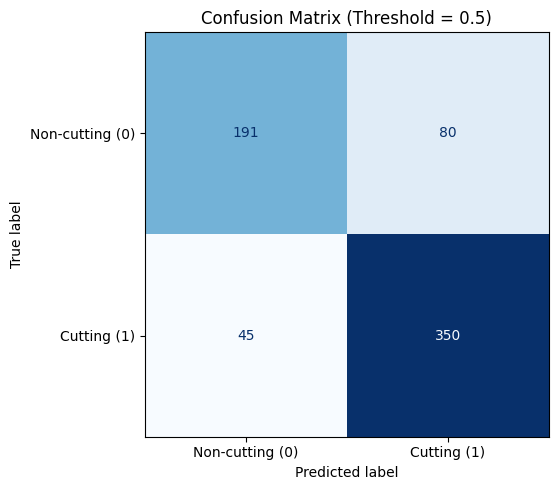

In [ ]:
# Test evaluation (held-out videos)
print("[phase=eval] Evaluating on validation videos")

# Load best checkpoint if available
if checkpoint_path.exists():
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))

model.eval()

test_loss = 0.0
test_acc = 0.0

all_probs = []
all_targets = []

test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb).squeeze(1)
        loss = criterion(logits, yb)

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

        test_loss += loss.item() * xb.size(0)
        test_acc += (preds == yb).float().mean().item() * xb.size(0)

        all_probs.append(probs.detach().cpu())
        all_targets.append(yb.detach().cpu())

if len(test_loader.dataset) > 0:
    test_loss /= len(test_loader.dataset)
    test_acc /= len(test_loader.dataset)                                                                                                                                                     
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

    # Confusion matrix
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    y_true = torch.cat(all_targets).numpy().astype(int)
    y_pred = (torch.cat(all_probs).numpy() >= 0.5).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-cutting (0)", "Cutting (1)"])
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title("Confusion Matrix (Threshold = 0.5)")
    plt.tight_layout()
    plt.show()
else:
    print("[warning] No test samples after filtering unknown labels.")


In [22]:
import numpy as np

print("[phase=eval] Binary class distribution (cutting=1, non-cutting=0)")

train_cutting = int((y_train == 1.0).sum())
train_non_cutting = int((y_train == 0.0).sum())
val_cutting = int((y_val == 1.0).sum())
val_non_cutting = int((y_val == 0.0).sum())
val_total = val_cutting + val_non_cutting

print(f"{'Class':<18} {'Train':>8} {'Val':>8} {'Val%':>8}")
print("-" * 46)
for class_name, train_count, val_count in [
    ("Cutting (1)", train_cutting, val_cutting),
    ("Non-cutting (0)", train_non_cutting, val_non_cutting),
]:
    val_pct = (val_count / val_total * 100.0) if val_total > 0 else 0.0
    print(f"{class_name:<18} {train_count:>8} {val_count:>8} {val_pct:>7.1f}%")

[phase=eval] Binary class distribution (cutting=1, non-cutting=0)
Class                 Train      Val     Val%
----------------------------------------------
Cutting (1)            3519      395    59.3%
Non-cutting (0)        3450      271    40.7%
